In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("StudentPerformance.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Maths_Score            29 non-null     int64
 1   Reading_Score          29 non-null     int64
 2   Writing_Score          29 non-null     int64
 3   Placement_Score        29 non-null     int64
 4   Club_Join_Date         29 non-null     int64
 5   Placement offer count  29 non-null     int64
dtypes: int64(6)
memory usage: 1.5 KB


In [2]:
df.isnull().sum()

Maths_Score              0
Reading_Score            0
Writing_Score            0
Placement_Score          0
Club_Join_Date           0
Placement offer count    0
dtype: int64

In [3]:
mean_val=df['Maths_Score'].mean()
df['Maths_Score']=df['Maths_Score'].fillna(mean_val)
mean_val=df['Reading_Score'].mean()
df['Reading_Score']=df['Reading_Score'].fillna(mean_val)
mean_val=df['Writing_Score'].mean()
df['Writing_Score']=df['Writing_Score'].fillna(mean_val)
mean_val=df['Placement_Score'].mean()
df['Placement_Score']=df['Placement_Score'].fillna(mean_val)
df.isnull().sum()

Maths_Score              0
Reading_Score            0
Writing_Score            0
Placement_Score          0
Club_Join_Date           0
Placement offer count    0
dtype: int64

<Axes: >

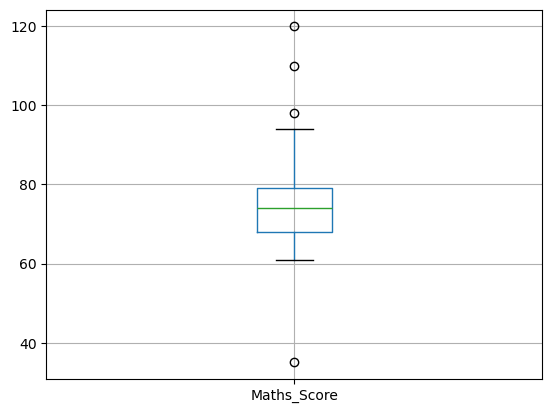

In [4]:
col=['Maths_Score']
df.boxplot(col)

In [5]:
sorted_df=sorted(df['Maths_Score'])
sorted_df
q1=np.percentile(sorted_df,25)
q3=np.percentile(sorted_df,75)
print(q1,q3)

68.0 79.0


In [6]:
IQR=q3-q1
lwr_bound=q1-(1.5*IQR)
upr_bound=q3+(1.5*IQR)
print(lwr_bound,upr_bound)

51.5 95.5


In [7]:
sample_outliers=df[col][(df[col]<lwr_bound)|(df[col]>upr_bound)]
sample_outliers

,Maths_Score
0,NaN
1,NaN
2,NaN
3,35.0
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [11]:
median=np.median(df[col])
median

np.float64(74.0)

In [13]:
index_outliers = df[(df['Maths_Score'] < lwr_bound) | (df['Maths_Score'] > upr_bound)].index

for i in index_outliers:
    df.at[i, 'Maths_Score'] = median
df

,Maths_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement offer count
0,70,93,61,82,2020,2
1,77,84,65,88,2019,3
2,69,84,68,93,2020,3
3,74,81,73,91,2019,3
4,78,95,73,96,2020,3
5,70,94,60,80,2020,2
6,69,86,79,91,2018,3
7,76,92,61,79,2019,2
8,79,81,77,80,2018,2
9,79,85,78,76,2020,2
